# **Finetuning del modelo de Gemma2-9b con Unsloth**

Hacemos el finetuning con Unsloth del modelo Gemma2-9b.

Lo cierto es que esta es la segunda vez que tuvimos que ejecutar el finetuning, porque el modelo que obtuvimos la primera vez, que fue el que mostramos en la práctica de LLM Engineering, encontramos que estaba en overfitting. Añadimos más detalles en la memoria del trabajo.

Comenzamos con la instalación de Unsloth, que necesita hacer después una reiniciación de la sesión.

In [ ]:
!pip install unsloth
!pip install --no-deps xformers trl peft accelerate bitsandbytes

Cargamos las funciones necesarias dentro de Unsloth, así como torch.

In [ ]:
from unsloth import FastLanguageModel
import torch

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


Definimos otros parámetros necesarios para el finetuning.

In [ ]:
max_seq_length = 2048 # Soporta hasta el límite de Gemma-2
dtype = None # Auto detección (Float16 para Tesla T4, Bfloat16 para A100/L4)
load_in_4bit = True # Usar cuantización de 4 bits para ahorrar memoria

Descargamos el modelo Gemma2-9b.

Nos sugiere que cargemos la librería flash-attn, pero lo hemos probado y tarda tanto que no lo hemos ejecutado finalmente. Gemini dice de todas formas que el finetuning debería de funcionar correctamente.

In [ ]:
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name = "unsloth/gemma-2-9b-it-bnb-4bit", # Versión optimizada de Gemma-2-9b
    max_seq_length = max_seq_length,
    dtype = dtype,
    load_in_4bit = load_in_4bit,
)

Unsloth: If you want to finetune Gemma 2, install flash-attn to make it faster!
To install flash-attn, do the below:

pip install --no-deps --upgrade "flash-attn>=2.6.3"
==((====))==  Unsloth 2026.2.1: Fast Gemma2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA L4. Num GPUs = 1. Max memory: 22.034 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 8.9. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/6.13G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/4.24M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/636 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/17.5M [00:00<?, ?B/s]

No ejecutar de nuevo la siguiente celda, tarda demasiado tiempo.

In [ ]:
pip install --no-deps --upgrade "flash-attn>=2.6.3"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 78.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


Añadimos los adaptadores de LoRA, optimizado para Unsloth.

In [ ]:
# Añadimos adaptadores LoRA para el fine-tuning
model = FastLanguageModel.get_peft_model(
    model,
    r = 16, # Rango sugerido (puedes subir a 32 si tienes memoria libre)
    target_modules = ["q_proj", "k_proj", "v_proj", "o_proj",
                      "gate_proj", "up_proj", "down_proj",],
    lora_alpha = 16,
    lora_dropout = 0, # Optimizado para 0 en Unsloth
    bias = "none",    # Optimizado para "none"
    use_gradient_checkpointing = "unsloth",
    random_state = 3407,
    use_rslora = False,
    loftq_config = None,
)

Unsloth 2026.2.1 patched 42 layers with 42 QKV layers, 42 O layers and 42 MLP layers.


Aquí ajustamos los datasets para hacer el finetuning. Lo cierto es que tuvimos que eliminar el campo de 'metadata', porque incluía en algunos casos listas (arrays), no solo texto, y daba errores.

In [ ]:
import pandas as pd
from datasets import Dataset, DatasetDict

def cargar_datos_seguro(ruta_train, ruta_test):
    # Pandas no se queja si una columna tiene tipos mezclados (la trata como 'object')
    df_train = pd.read_json(ruta_train, lines=True)
    df_test = pd.read_json(ruta_test, lines=True)

    # Opcional: Nos quedamos solo con lo que el modelo necesita para el fine-tuning
    # Esto evita que metadata cause errores más adelante
    df_train = df_train[['input_text', 'target_text']]
    df_test = df_test[['input_text', 'target_text']]

    # Convertimos de Pandas a Hugging Face Dataset
    ds_train = Dataset.from_pandas(df_train)
    ds_test = Dataset.from_pandas(df_test)

    return DatasetDict({"train": ds_train, "test": ds_test})

Cargamos los datasets y les aplicamos la función anterior.

In [ ]:
dataset = cargar_datos_seguro(
    "/content/drive/MyDrive/Practica_Bootcamp_IA_4/dataset_unificado_2011-19_corr/train.jsonl",
    "/content/drive/MyDrive/Practica_Bootcamp_IA_4/dataset_unificado_2011-19_corr/test.jsonl"
)

Formateamos los prompts para que sea compatible con el modelo.

In [ ]:
prompt_style = """{}

{}

{}""" # Estructura: Instrucción, Contexto, Respuesta

def formatting_prompts_func(examples):
    inputs  = examples["input_text"]
    outputs = examples["target_text"]
    texts = []
    for input_text, output_text in zip(inputs, outputs):
        # Aquí SÍ usamos prompt_style para dar formato
        # El input_text ya trae los ### del JSONL, así que solo concatenamos
        text = prompt_style.format(input_text, "", output_text) + tokenizer.eos_token
        texts.append(text)
    return { "text" : texts, }

# Aplicamos el formato a ambos sets
dataset = dataset.map(formatting_prompts_func, batched = True)

Map:   0%|          | 0/1600 [00:00<?, ? examples/s]

Map:   0%|          | 0/200 [00:00<?, ? examples/s]

Hacemos el finetuning, que me llevó algo más de una hora, y mostramos los errores de training y validación, estos últimos proveniente del dataset de test.

En esta segundo finetuning nos aseguramos que el proceso se acaba cuando el validation loss empieza a subir, siquiera ligeramente, evitando así que el modelo en realidad memorice las respuestas y entre de facto en overfitting. De los 600 batches previstos, solo se ejecutaron en el finetuning 440.

In [ ]:
from trl import SFTTrainer
from transformers import TrainingArguments
from transformers import EarlyStoppingCallback

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    train_dataset = dataset["train"],
    eval_dataset = dataset["test"],
    dataset_text_field = "text",
    max_seq_length = max_seq_length,
    # --- AÑADIMOS EL CALLBACK ---
    callbacks = [EarlyStoppingCallback(early_stopping_patience = 2)],
    args = TrainingArguments(
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 8,
        warmup_steps = 5,
        num_train_epochs = 3, # Dejamos 3 como límite máximo, pero parará antes
        learning_rate = 1e-4, # Bajamos un poco a 1e-4 para un aprendizaje más fino
        fp16 = not torch.cuda.is_bf16_supported(),
        bf16 = torch.cuda.is_bf16_supported(),

        # --- CONFIGURACIÓN DE EVALUACIÓN Y GUARDADO ---
        eval_strategy = "steps",
        eval_steps = 20,              # Evaluamos cada 20 pasos
        save_steps = 20,              # DEBE ser igual a eval_steps para que funcione EarlyStopping
        logging_steps = 1,
        save_total_limit = 2,         # Solo guarda los 2 mejores modelos para no llenar el Drive
        load_best_model_at_end = True, # ¡CRÍTICO! Al terminar, carga el modelo con menor loss
        metric_for_best_model = "eval_loss",

        optim = "adamw_8bit",
        weight_decay = 0.01,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        save_strategy = "steps",      # Cambiamos de "no" a "steps"
    ),
)

trainer_stats = trainer.train()

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/1600 [00:00<?, ? examples/s]

Unsloth: Tokenizing ["text"] (num_proc=16):   0%|          | 0/200 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,600 | Num Epochs = 3 | Total steps = 600
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 8
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 8 x 1) = 8
 "-____-"     Trainable parameters = 54,018,048 of 9,295,724,032 (0.58% trained)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 3


wandb: You chose "Don't visualize my results"
wandb: Using W&B in offline mode.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference, openai] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Step,Training Loss,Validation Loss
20,1.199300,0.784443
40,0.715700,0.577125
60,0.413500,0.473449
80,0.592500,0.421906
100,0.291000,0.387793
120,0.819600,0.371123
140,0.819400,0.359956
160,0.666200,0.353231
180,0.253700,0.346079
200,0.682300,0.339615


Unsloth: Not an error, but Gemma2ForCausalLM does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wandb: WARNING URL not available in offline run
wan

eval/loss,█▅▃▃▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/runtime,█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
eval/samples_per_second,▁█████████████████████
eval/steps_per_second,▁█████████████████████
train/epoch,▁▁▁▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▄▅▅▆▆▆▆▆▆▇▇▇▇█████
train/global_step,▁▁▁▁▂▂▂▂▃▃▃▃▃▃▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▆▆▆▇▇▇█████
train/grad_norm,▄▃▄▃▄▃▆▂▂▄▄▄▂▃▃▄▄▄▂▃▅▄▆▂▁▄▁▁▂▁▂▄▂▅▅█▃▁▃█
train/learning_rate,██████▇▇▇▇▇▇▇▆▆▆▆▆▆▆▅▅▄▄▄▃▃▃▃▃▂▂▂▂▂▂▁▁▁▁
train/loss,█▆▅▄▇▂▇▂▇▅▅▄▁▃▂▁▄▂▄▂▅▂▁▂▃▁▄▄▄▃▂▂▁▁▂▃▄▂▂▄
eval/loss,0.32276
eval/runtime,47.354


He aquí la gráfica que muestra las losses de train y validación. El dato del validation loss, 0.32, pensamos que es muy bueno.

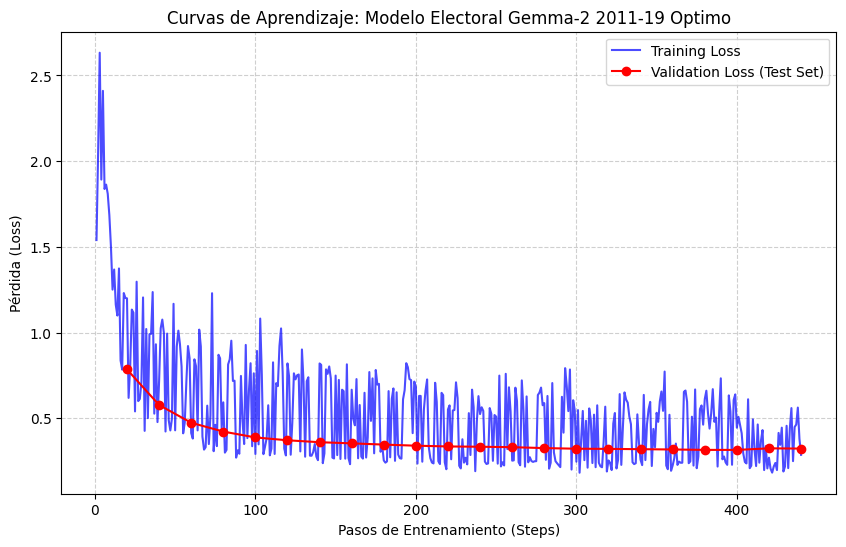

In [ ]:
import matplotlib.pyplot as plt

# Extraer los logs del historial del trainer
history = trainer.state.log_history

train_loss = [x['loss'] for x in history if 'loss' in x]
train_steps = [x['step'] for x in history if 'loss' in x]

val_loss = [x['eval_loss'] for x in history if 'eval_loss' in x]
val_steps = [x['step'] for x in history if 'eval_loss' in x]

# Crear la gráfica
plt.figure(figsize=(10, 6))
plt.plot(train_steps, train_loss, label='Training Loss', color='blue', alpha=0.7)
if val_loss:
    plt.plot(val_steps, val_loss, label='Validation Loss (Test Set)', color='red', marker='o')

plt.title('Curvas de Aprendizaje: Modelo Electoral Gemma-2 2011-19 Optimo')
plt.xlabel('Pasos de Entrenamiento (Steps)')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
plt.savefig('/content/drive/MyDrive/Practica_Bootcamp_IA_4/grafica_entrenamiento_gemma_2-9b_2011-19_Optimo.png')

<Figure size 640x480 with 0 Axes>

In [ ]:
# model.save_pretrained_merged("/content/drive/MyDrive/Practica_Bootcamp_IA_4/modelo-Gemma_2-9b_2011-19_finetuned-4bit", tokenizer, save_method = "merged_4bit_forced")

Ahora guardamos el modelo en 4bits, para que no ocupe demasiado en nuestro Drive.

In [ ]:
ruta_modelo_final = "/content/drive/MyDrive/Practica_Bootcamp_IA_4/modelo-Gemma_2-9b_FINAL_5_elecciones"

In [ ]:
# 2. Guardar el modelo fusionado en 4 bits
# Usamos 'merged_4bit_forced' para que sea compatible con tu App de Streamlit
model.save_pretrained_merged(
    ruta_modelo_final,
    tokenizer,
    save_method = "merged_4bit_forced"
)

print(f"¡Modelo guardado con éxito en: {ruta_modelo_final}")

config.json:   0%|          | 0.00/927 [00:00<?, ?B/s]

Unsloth: Merging LoRA weights into 4bit model...


/usr/local/lib/python3.12/dist-packages/peft/tuners/lora/bnb.py:397: UserWarning: Merge lora module to 4-bit linear may get different generations due to rounding errors.
  warnings.warn(


Unsloth: Merging finished.
Unsloth: Found skipped modules: ['lm_head']. Updating config.
Unsloth: Saving merged 4bit model to /content/drive/MyDrive/Practica_Bootcamp_IA_4/modelo-Gemma_2-9b_FINAL_5_elecciones...
Unsloth: Merged 4bit model saved.
Unsloth: Merged 4bit model process completed.
¡Modelo guardado con éxito en: /content/drive/MyDrive/Practica_Bootcamp_IA_4/modelo-Gemma_2-9b_FINAL_5_elecciones


Aprovechamos que tenemos el modelo en nuestra RAM para subirlo a Hugging Face.

Obviamente, no mostramos la key.

In [ ]:
from huggingface_hub import login

In [ ]:
login('Mi_key_HF')

In [ ]:
hf_model_id = "GuillermoBarrio/modelo-Gemma_2-9b-electoral-5-elecciones"

model.push_to_hub_merged(
    hf_model_id,
    tokenizer,
    save_method = "merged_4bit_forced",
    token = True # Usa el token con el que te logueaste
)

Unsloth: Merging LoRA weights into 4bit model...
Unsloth: Merging finished.
Unsloth: Found skipped modules: ['lm_head']. Updating config.
Unsloth: Saving merged 4bit model to GuillermoBarrio/modelo-Gemma_2-9b-electoral-5-elecciones...
Unsloth: Merged 4bit model saved.


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...lecciones/tokenizer.model: 100%|##########| 4.24MB / 4.24MB            

  ...elecciones/tokenizer.json: 100%|##########| 34.4MB / 34.4MB            

  ...0001-of-00002.safetensors:   0%|          |  601kB / 4.98GB            

  ...0002-of-00002.safetensors:   0%|          |  527kB / 1.15GB            

Unsloth: Merged 4bit model process completed.


Podemos también guardar los logs de output runs, por si hiciesen falta algún día.

In [ ]:
!tar -czvf logs_entrenamiento.tar.gz /content/outputs/runs

tar: Removing leading `/' from member names
/content/outputs/runs/
/content/outputs/runs/Feb21_14-57-29_afaa888a0693/
/content/outputs/runs/Feb21_14-57-29_afaa888a0693/events.out.tfevents.1771685874.afaa888a0693.2171.0


Limpiamos el espacio antes de desconectar.

In [ ]:
import shutil
import os

# Borrar la carpeta de outputs por completo
if os.path.exists("outputs"):
    shutil.rmtree("outputs")
    print("Carpeta 'outputs' eliminada. Espacio liberado.")

Carpeta 'outputs' eliminada. Espacio liberado.
